# Titanik Veri Seti İncelemesi ve Yarışma Tahmini
Bu notdefterinde Titanik veri seti veri görseleştirme, keşifsel veri analizi....

1. Kütüphanelerin Yüklenmesi

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Çıktı hücresindeki uyarıları kapatmak için
import warnings
warnings.filterwarnings('ignore')

2. Veri setlerini yükleme

In [3]:
df_train=pd.read_csv(r'/kaggle/input/titanic/train.csv')
df_test=pd.read_csv(r'/kaggle/input/titanic/test.csv')


In [4]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


3. Veri İnceleme & Önişleme
* Keşifsel Veri Analizi (EDA)
* Veri Görselleştirme
* Eksik verilerin işlenmesi
* Özellikleri belirleme ve Dönüştürme
* Veri setinin (X-y) ayrılması (Feature-Target)
* Veri setinin eğitim-doğrulama-test olarak ayrılması

In [6]:
# veri setlerine bakalım info()
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
#Eksik verilerin sayısını gösterir
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df_test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [9]:
# Tanımlayıcı İstatistikler tüm özellikleri incele
df_train.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [10]:
#Kategorik özellikleri ve sayısal özellikleri belirlemek
#df_train['Pclass']=df_train['Pclass'].cat.set_categories([3,2,1], ordered=True)
df_train['Pclass'].dtype

dtype('int64')

In [11]:
df_train['Sex']=df_train['Sex'].astype('category')
df_train['Sex'].dtype

CategoricalDtype(categories=['female', 'male'], ordered=False, categories_dtype=object)

In [12]:
df_train['Embarked']=df_train['Embarked'].astype('category')
df_train['Embarked'].dtype

CategoricalDtype(categories=['C', 'Q', 'S'], ordered=False, categories_dtype=object)

In [13]:
df_test.describe(include='all')

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,418.000000,418.000000,418,418,332.000000,418.000000,418.000000,418,417.000000,91,418
unique,NaN,NaN,418,2,NaN,NaN,NaN,363,NaN,76,3
top,NaN,NaN,"Peter, Master. Michael J",male,NaN,NaN,NaN,PC 17608,NaN,B57 B59 B63 B66,S
freq,NaN,NaN,1,266,NaN,NaN,NaN,5,NaN,3,270
mean,1100.500000,2.265550,NaN,NaN,30.272590,0.447368,0.392344,NaN,35.627188,NaN,NaN
std,120.810458,0.841838,NaN,NaN,14.181209,0.896760,0.981429,NaN,55.907576,NaN,NaN
min,892.000000,1.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,996.250000,1.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,1100.500000,3.000000,NaN,NaN,27.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1204.750000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.500000,NaN,NaN


In [14]:
#Sayısal özellikler
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
#Kategorik özellikler için betimsel istatistikler
df_train.describe(include=['object','category'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [16]:
# Ölüm / Kalım sayısı
df_train['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [17]:
# Ölüm / Kalım oransal değeri
df_train['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

<Axes: ylabel='proportion'>

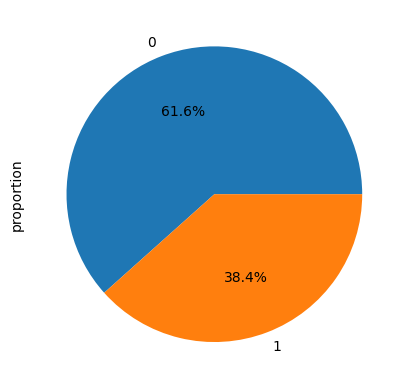

In [18]:
df_train['Survived'].value_counts(normalize=True).plot(kind='pie',
                                                       autopct='%.1f%%')

# SeaBorn kütüphanesiyle daha iyi ver görselleştirme yapılabilir
* countplot : kategorik değişkenlerdeki sayıları verir
* data: veri seti
* x: x eksenindeki özellik
* palette: renk paleti
* hue: kategorik bir değişken
* plt.title('Grafiğin Başlığı')
* plt.xlabel('X ekseni Etiketi')
* plt.xlabel('Y ekesnei Etiketi')
* plt.show() # Grafiği göster

### Cinsiyete Göre Hayatta Kalma Durumları

In [19]:
df_train.groupby('Sex')['Survived'].value_counts()

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

In [20]:
#Cinsiyete Göre Hayatta Kalma Durumu
df_train.groupby('Sex')['Survived'].value_counts(normalize=True)

Sex     Survived
female  1           0.742038
        0           0.257962
male    0           0.811092
        1           0.188908
Name: proportion, dtype: float64

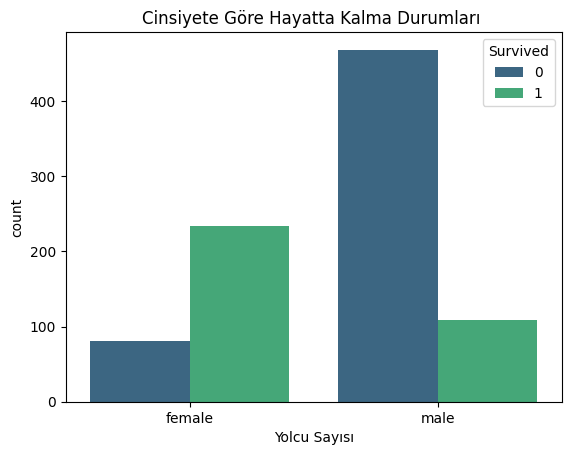

In [21]:
sns.countplot(data=df_train,
             x='Sex',
             hue='Survived',
             palette='viridis')
plt.title('Cinsiyete Göre Hayatta Kalma Durumları ')
plt.xlabel('Cinsiyet')
plt.xlabel('Yolcu Sayısı')
plt.show()


<Axes: title={'center': 'Erkeklerde Hayatta Kalma Oranı'}, ylabel='count'>

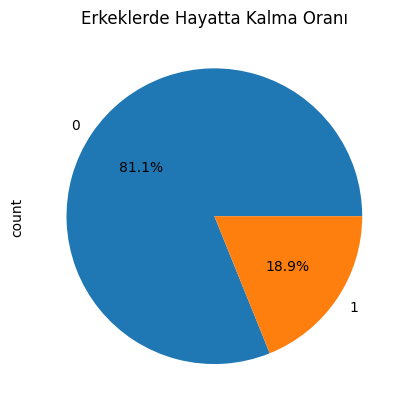

In [22]:
#sadece erkeklerin olduğu bir veri seti
df_train_male=df_train[df_train['Sex']=='male']
df_train_male['Survived'].value_counts().plot(kind='pie',
                                             autopct='%1.1f%%',
                                             title='Erkeklerde Hayatta Kalma Oranı')

<Axes: title={'center': 'Kadınlarda Hayatta Kalma Oranı'}, ylabel='count'>

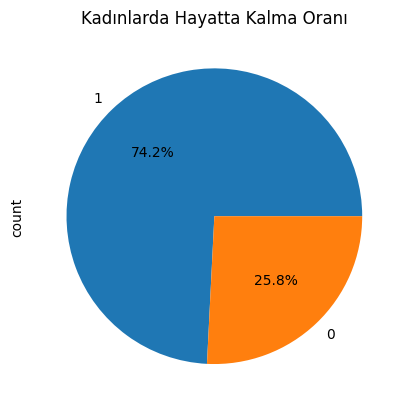

In [23]:
#sadece erkeklerin olduğu bir veri seti
df_train_female=df_train[df_train['Sex']=='female']
df_train_female['Survived'].value_counts().plot(kind='pie',
                                             autopct='%1.1f%%',
                                             title='Kadınlarda Hayatta Kalma Oranı')

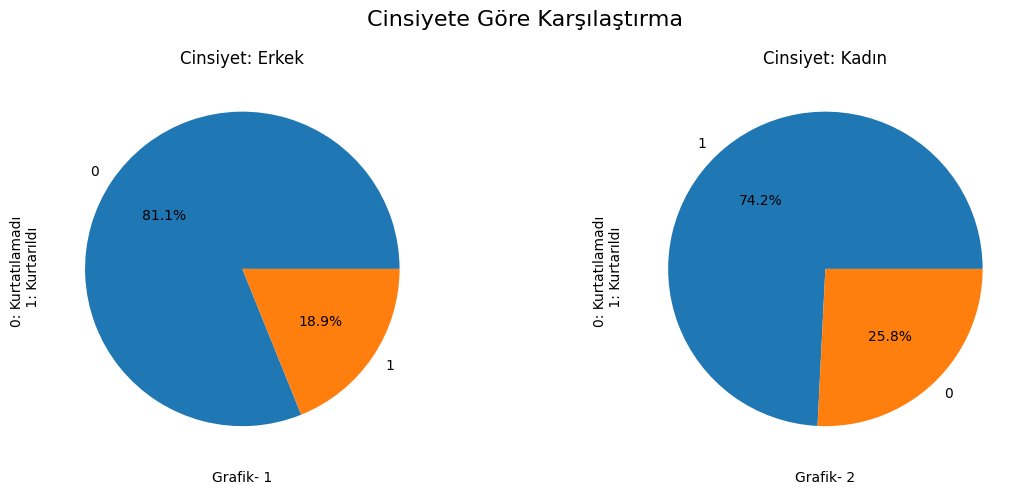

In [24]:
# Cinsiyete göre   karşılaştırmalı
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Cinsiyete Göre Karşılaştırma', fontsize=16) # Grafik başlığı
for i, sex in enumerate(['male', 'female']):
    df_sex = df_train[df_train['Sex'] == sex]
    df_sex['Survived'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[i])
    sex_tr=['Erkek', 'Kadın'] # Türkçe'ye çevir
    axes[i].set_title(f'Cinsiyet: {sex_tr[i]}')
    axes[i].set_ylabel('0: Kurtatılamadı \n 1: Kurtarıldı')
    axes[i].set_xlabel(f'Grafik- {i+1}')
plt.tight_layout()
plt.show()

In [25]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    category
dtypes: category(2), float64(2), int64(5), object(3)
memory usage: 71.7+ KB


### Yolculuk Sınıfına Göre Hayatta Kalma Durumları

In [26]:
df_train.groupby('Pclass')['Survived'].value_counts()

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

In [27]:
df_train.groupby('Pclass')['Survived'].value_counts(normalize=True)

Pclass  Survived
1       1           0.629630
        0           0.370370
2       0           0.527174
        1           0.472826
3       0           0.757637
        1           0.242363
Name: proportion, dtype: float64

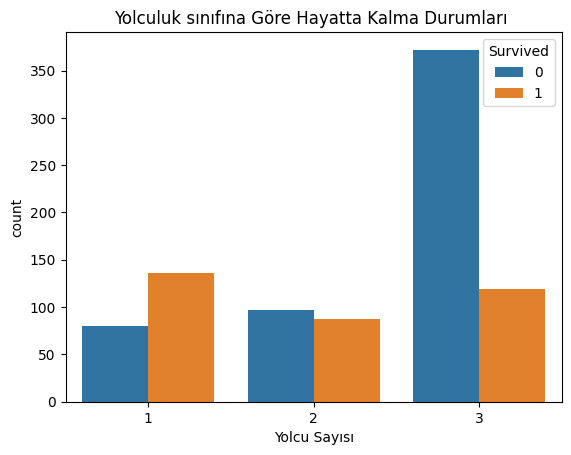

In [28]:
sns.countplot(data=df_train,
             x='Pclass',
             hue='Survived')
plt.title('Yolculuk sınıfına Göre Hayatta Kalma Durumları ')
plt.xlabel('PClass')
plt.xlabel('Yolcu Sayısı')
plt.show()


In [29]:
df_train['Pclass'].dtype

dtype('int64')

<Axes: title={'center': 'P1 de Hayatta Kalma Oranı'}, ylabel='count'>

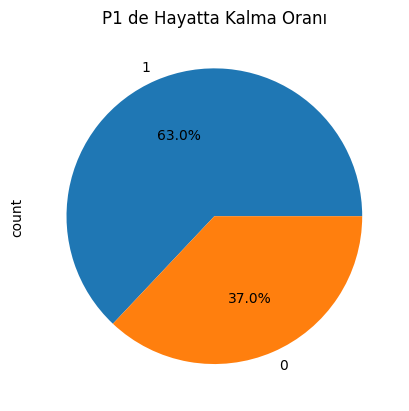

In [30]:
#sadece P1 lerin olduğu bir veri seti
df_train_pclass1=df_train[df_train['Pclass']==1]
df_train_pclass1['Survived'].value_counts().plot(kind='pie',
                                             autopct='%1.1f%%',
                                             title='P1 de Hayatta Kalma Oranı')

<Axes: title={'center': 'P2 de Hayatta Kalma Oranı'}, ylabel='count'>

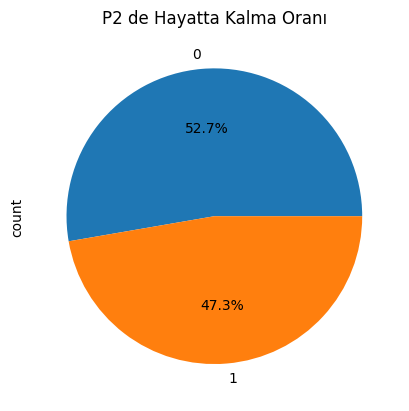

In [31]:
#sadece P2 lerin olduğu bir veri seti
df_train_pclass2=df_train[df_train['Pclass']==2]
df_train_pclass2['Survived'].value_counts().plot(kind='pie',
                                             autopct='%1.1f%%',
                                             title='P2 de Hayatta Kalma Oranı')

<Axes: title={'center': 'P3 de Hayatta Kalma Oranı'}, ylabel='count'>

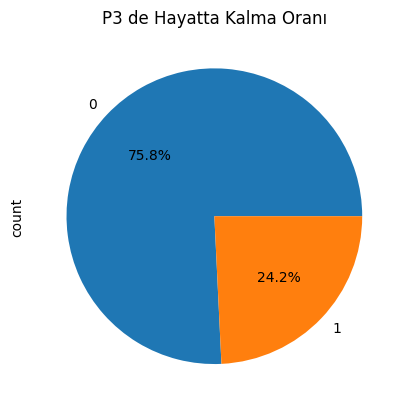

In [32]:
#sadece P3 lerin olduğu bir veri seti
df_train_pclass3=df_train[df_train['Pclass']==3]
df_train_pclass3['Survived'].value_counts().plot(kind='pie',
                                             autopct='%1.1f%%',
                                             title='P3 de Hayatta Kalma Oranı')

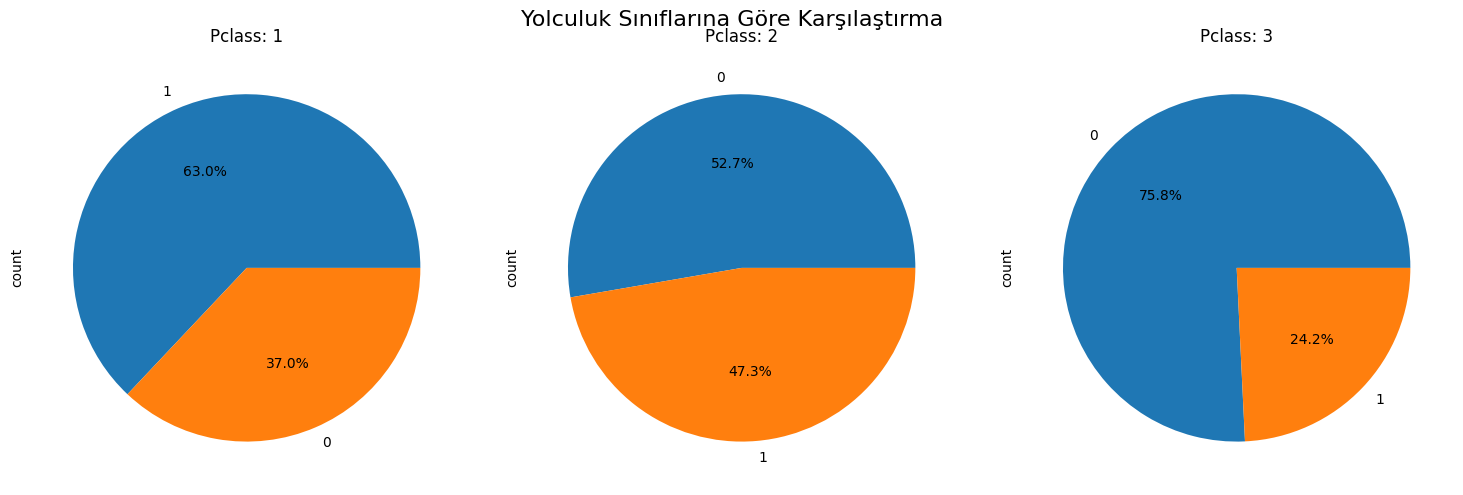

In [33]:
# Yolculuk sınıflarını ek bir graifkle karşılaştıırlması
fig,axes=plt.subplots(1,3, figsize=(15,5)) # alt graifkler oluştur 1 satır 3 sütun 15,5 büyüklüğünde
fig.suptitle('Yolculuk Sınıflarına Göre Karşılaştırma', fontsize=16)
for i, pclass in enumerate([1,2,3]): #
    df_pclass=df_train[df_train['Pclass']==pclass]
    df_pclass['Survived'].value_counts().plot(kind='pie',
                                             autopct='%1.1f%%',
                                             ax=axes[i])
    axes[i].set_title(f'Pclass: {pclass}')
plt.tight_layout()
plt.show()    

## Yolculuk sınıfına göre Cinsyet Değişkenini incelenmesi

In [34]:
df_train.groupby(['Pclass','Sex'])['Survived'].value_counts()

Pclass  Sex     Survived
1       female  1            91
                0             3
        male    0            77
                1            45
2       female  1            70
                0             6
        male    0            91
                1            17
3       female  0            72
                1            72
        male    0           300
                1            47
Name: count, dtype: int64

In [35]:

df_train.groupby(['Pclass','Sex'])['Survived'].value_counts(normalize=True)

Pclass  Sex     Survived
1       female  1           0.968085
                0           0.031915
        male    0           0.631148
                1           0.368852
2       female  1           0.921053
                0           0.078947
        male    0           0.842593
                1           0.157407
3       female  0           0.500000
                1           0.500000
        male    0           0.864553
                1           0.135447
Name: proportion, dtype: float64

In [36]:
#Hayatını kaybeden kişilerş sorgulama
#P1 de hayatıunı kaybeden kadın yolcular
df_train[(df_train['Pclass']==1) &(df_train['Sex']=='female') & (df_train['Survived']==0)][['Name', 'Age']]

,Name,Age
177,"Isham, Miss. Ann Elizabeth",50.0
297,"Allison, Miss. Helen Loraine",2.0
498,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",25.0


In [37]:
# özel greuptaki kişi sayısı 
len(df_train[(df_train['Pclass']==1) &(df_train['Sex']=='female') & (df_train['Survived']==0)])

3

In [38]:
df_train[(df_train['Pclass']==1) &(df_train['Sex']=='female') & (df_train['Survived']==0)].value_counts().sum()

np.int64(3)

Evet, Miss. Helen Loraine Allison ve Mrs. Hudson J C (Bessie Waldo Daniels) Allison anne-kız ilişkisindedir.

Aile Bağlantısı
Titanic yolcusu listesinde belirtilen bu iki kişi, Kanada kökenli zengin Allison ailesinin üyeleridir. Helen Loraine Allison (doğum 1909), Hudson J.C. Allison ve eşi Bessie Waldo Daniels'ın kızıdır.

In [39]:
#isme göre arama
df_train[df_train['Name'].str.contains('Allison')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
297,298,0,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.55,C22 C26,S
305,306,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.55,C22 C26,S
498,499,0,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.55,C22 C26,S


In [40]:
#isme göre arama
#isim=input('Aranacak isim boşluk bırakmadan tek isim oalrak girin:')
#df_train[df_train['Name'].str.contains(isim, case=False)] # case sensiteve olmaz

In [41]:
# 5 yaşın altında hayatını kaybeden çocuklar
#df_train[df_train['Age']<=5].groupby('Pclass').value_counts()

In [46]:
#En yaşlı yolcunun yaşını
df_train['Age'].max()

80.0

In [48]:
df_train[df_train['Age']>=80]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0,A23,S


In [49]:
# en yaşlı kişi(ler)
df_train[df_train['Age']==df_train['Age'].max()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0,A23,S


In [50]:
#train en küçük yolcu
df_train[df_train['Age']==df_train['Age'].min()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C


https://www.encyclopedia-titanica.org/titanic-survivor/assad-alexander-thomas-tannous.html

In [127]:
df_test[df_test['Age']==df_test['Age'].min()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
354,1246,3,"Dean, Miss. Elizabeth Gladys Millvina""""",female,0.17,1,2,C.A. 2315,20.575,NaN,S


https://tr.wikipedia.org/wiki/Millvina_Dean#:~:text=Elizabeth%20Gladys%20Millvina%20Dean%20(d,zamanda%20gemideki%20en%20gen%C3%A7%20yolcuydu.

In [77]:
# arama fonksiyonu tuple döndürür (Aranan kişi var/Yok, kaç kayıt var, df_list)
def arama(ad='Thomas'): # varsayılan parametre 
    """
    Örnek 1: Eşleşme varsa
    sonuc = arama('Allison')
    Çıktı: (True, 4, df ile Allison satırları)
    
    """
    sayac=len(df_train[df_train['Name'].str.contains(ad,case=False)])
    if sayac>0:
        return True,sayac,df_train[df_train['Name'].str.contains(ad,case=False)]  # tuple
    else: return False, sayac, False

In [78]:
help(arama)

Help on function arama in module __main__:

arama(ad)
    Örnek 1: Eşleşme varsa
    sonuc = arama('Allison')
    Çıktı: (True, 4, df ile Allison satırları)



In [67]:
arama('Murat')[1] # kayıt sayısını

0

In [68]:
arama('thomas')[0] # olup olmadığını

True

In [69]:
arama('thomas')[2] # bu ise Data Frame

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
149,150,0,2,"Byles, Rev. Thomas Roussel Davids",male,42.00,0,0,244310,13.0000,NaN,S
151,152,1,1,"Pears, Mrs. Thomas (Edith Wearne)",female,22.00,1,0,113776,66.6000,C2,S
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.5500,NaN,S
186,187,1,3,"O'Brien, Mrs. Thomas (Johanna ""Hannah"" Godfrey)",female,NaN,1,0,370365,15.5000,NaN,Q
252,253,0,1,"Stead, Mr. William Thomas",male,62.00,0,0,113514,26.5500,C87,S
260,261,0,3,"Smith, Mr. Thomas",male,NaN,0,0,384461,7.7500,NaN,Q
336,337,0,1,"Pears, Mr. Thomas Clinton",male,29.00,1,0,113776,66.6000,C2,S
347,348,1,3,"Davison, Mrs. Thomas Henry (Mary E Finck)",female,NaN,1,0,386525,16.1000,NaN,S
364,365,0,3,"O'Brien, Mr. Thomas",male,NaN,1,0,370365,15.5000,NaN,Q
372,373,0,3,"Beavan, Mr. William Thomas",male,19.00,0,0,323951,8.0500,NaN,S


In [70]:
arama('turhan')[2] # olup olmadığını

False

In [79]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    category
dtypes: category(2), float64(2), int64(5), object(3)
memory usage: 71.7+ KB


Text(0, 0.5, 'sayı')

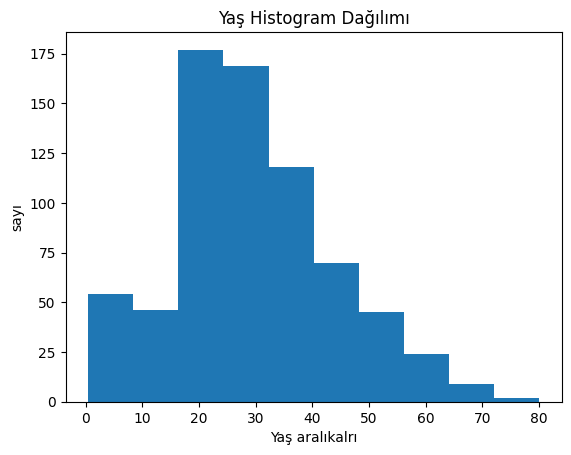

In [86]:
# Age - Histogram grafiği
df_train['Age'].plot(kind='hist', 
                     bins=10) # kind histogram demek bins ise bu histogramın kaç gruptan oluşacağını belirler
plt.title("Yaş Histogram Dağılımı")
plt.xlabel("Yaş aralıkalrı")
plt.ylabel("sayı")


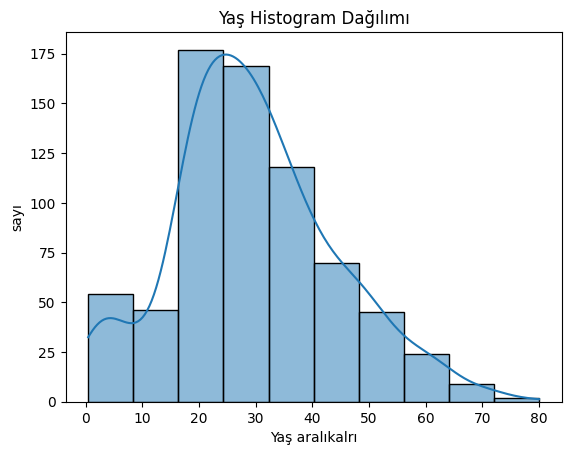

In [94]:
#seaborn de yaş dağılım grafiği
sns.histplot(data=df_train,
            x='Age',
            bins=10,
            kde=True)

plt.title("Yaş Histogram Dağılımı")
plt.xlabel("Yaş aralıkalrı")
plt.ylabel("sayı")
plt.show()

Titanic’e bilet alıp gemiye binemeyen ve bu sayede faciadan kurtulan Türk, kadın doğum uzmanı Prof. Dr. Besim Ömer Akalın’dır.​

Kimdir? Besim Ömer Akalın, Osmanlı döneminin önde gelen hekimlerinden, Türkiye’de modern doğum hastaneleri ve ebeliğin kurumsallaşmasında önemli rol oynayan bir tıp profesörüdür.​

In [88]:
arama('besim')

(False, 0, False)

In [89]:
len(df_test[df_test['Name'].str.contains('besim',case=False)])

0

In [93]:
#Bilet ücretleri
df_train['Fare'].max(), df_train['Fare'].min(),df_train['Fare'].mean(), df_train['Fare'].median()

(512.3292, 0.0, np.float64(32.204207968574636), 14.4542)

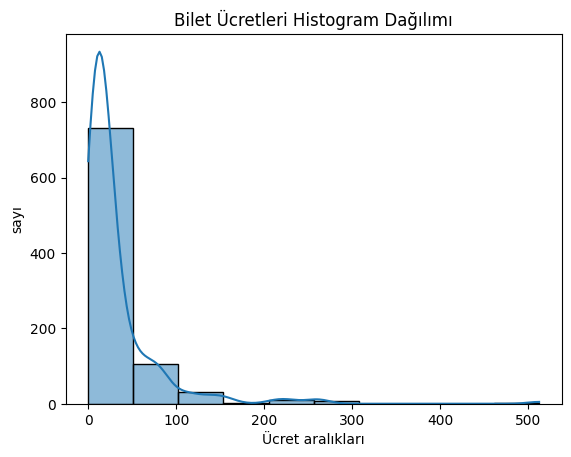

In [95]:
#seaborn de yaş dağılım grafiği
sns.histplot(data=df_train,
            x='Fare',
            bins=10,
            kde=True)

plt.title("Bilet Ücretleri Histogram Dağılımı")
plt.xlabel("Ücret aralıkları")
plt.ylabel("sayı")
plt.show()

In [98]:
# Pclass lara göre Fare ortalamaları
df_train.groupby('Pclass')['Fare'].min(), df_train.groupby('Pclass')['Fare'].max(), df_train.groupby('Pclass')['Fare'].mean(),df_train.groupby('Pclass')['Fare'].median(),    

(Pclass
 1    0.0
 2    0.0
 3    0.0
 Name: Fare, dtype: float64,
 Pclass
 1    512.3292
 2     73.5000
 3     69.5500
 Name: Fare, dtype: float64,
 Pclass
 1    84.154687
 2    20.662183
 3    13.675550
 Name: Fare, dtype: float64,
 Pclass
 1    60.2875
 2    14.2500
 3     8.0500
 Name: Fare, dtype: float64)

In [97]:
df_train.groupby('Pclass')['Fare'].min()

Pclass
1    0.0
2    0.0
3    0.0
Name: Fare, dtype: float64

In [99]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    category
dtypes: category(2), float64(2), int64(5), object(3)
memory usage: 71.7+ KB


In [102]:
#Sibsp: Siblings/Spouses Aboard Gemideki kardeş/eş sayısı
# 0 ise kardeşi veya eşi yok.
#Parch: Parent and children Aoard (Gemideki ebeveyn/çocuk sayısı)


In [103]:
#Yalnız seyahat edenler
df_train_ylnz=df_train[(df_train['SibSp']==0) & (df_train['Parch']==0)]
len (df_train_ylnz)/len (df_train)

0.6026936026936027

In [113]:
#Yalnız seyahat edenler
df_train_notylnz=df_train[(df_train['SibSp']>0) | (df_train['Parch']>0)]
len (df_train_notylnz)/len (df_train)

0.39730639730639733

In [107]:
# yalnız eşiyle seyahat edenler
df_train_es=df_train[(df_train['SibSp']==1) & (df_train['Parch']==0) & (df_train['Age']>=18)]
len(df_train_es)/len (df_train)

0.10549943883277217

In [119]:
df_train_ylnz['Survived'].value_counts(normalize=True),  df_train_notylnz['Survived'].value_counts(normalize=True),df_train['Survived'].value_counts(normalize=True)

(Survived
 0    0.696462
 1    0.303538
 Name: proportion, dtype: float64,
 Survived
 1    0.50565
 0    0.49435
 Name: proportion, dtype: float64,
 Survived
 0    0.616162
 1    0.383838
 Name: proportion, dtype: float64)

In [117]:
df_train_ylnz.groupby('Sex')['Survived'].value_counts(normalize=True), df_train_notylnz.groupby('Sex')['Survived'].value_counts(normalize=True)

(Sex     Survived
 female  1           0.785714
         0           0.214286
 male    0           0.844282
         1           0.155718
 Name: proportion, dtype: float64,
 Sex     Survived
 female  1           0.712766
         0           0.287234
 male    0           0.728916
         1           0.271084
 Name: proportion, dtype: float64)

In [120]:
df_train_es['Survived'].value_counts(normalize=True)

Survived
0    0.510638
1    0.489362
Name: proportion, dtype: float64

In [122]:
df_train.groupby('Parch')['Survived'].value_counts()

Parch  Survived
0      0           445
       1           233
1      1            65
       0            53
2      0            40
       1            40
3      1             3
       0             2
4      0             4
5      0             4
       1             1
6      0             1
Name: count, dtype: int64

In [121]:
#parch
df_train.groupby('Parch')['Survived'].value_counts(normalize=True)

Parch  Survived
0      0           0.656342
       1           0.343658
1      1           0.550847
       0           0.449153
2      0           0.500000
       1           0.500000
3      1           0.600000
       0           0.400000
4      0           1.000000
5      0           0.800000
       1           0.200000
6      0           1.000000
Name: proportion, dtype: float64

In [125]:
df_train[df_train['Age']<=12]['Survived'].value_counts(), df_train[df_train['Age']<=12]['Survived'].value_counts(normalize=True)

(Survived
 1    40
 0    29
 Name: count, dtype: int64,
 Survived
 1    0.57971
 0    0.42029
 Name: proportion, dtype: float64)

In [126]:
len(df_train) + len (df_test)

1309

"Titanic Passengers and Crew Complete List" Kaggle'da 2.200+ mürettebatı (güverte, makinistler, hizmetçiler) isim, rol, yaş ve kaderiyle listeliyor.

## **Rapor** 
### Genel
* Train veri setindeki tüm yolcuların % 62 si hayatını kaybetmiş.
### Cinsiyet Değişkeni
* Kadınların %74'ü (233) kurtulurken % 26'sı (81) hayatını kaybetmiş
* Erkeklerin %19'u (109) kurtulurken % 81'i (468) hayatını kaybetmiş
### Yolculuk Sınıfına Göre 
* 1.sınıf yolculardan % 63 ü (136) kurtulmuş % 37 (86) si kurtarılamamış
* 2.sınıf yolculardan % 47 ü (87) kurtulmuş % 53 (97) si kurtarılamamış
* 3.sınıf yolculardan % 24 ü (119) kurtulmuş %76 (372)  si kurtarılamamış
* 1.sınıf yolculuk yapan kadınların %97 si kurtulmuş (91-3)
* 1.sınıf yolculuk yapan erkeklerden %37 si (45-77) kurtulmuş
* 2.sınıf yolculuk yapan kadınlardan %92 si (70-6) kurtulmuş
* 2.sınıf yolculuk yapan erkeklerden %16 si (17-91) kurtulmuş
* 2.sınıf yolculuk yapan kadınlardan %92 si (70-6) kurtulmuş--
* 2.sınıf yolculuk yapan erkeklerden %16 si (17-91) kurtulmuş---
* Gemideki yolcuların % 60 ı yalnız seyahet ediyor
* Yalnız seyahet edenlerin kurtulma oranı %30 iken yanında en az bir kişi olanların %50 genel ortaladama ise bu oran % 38,
* 
*
* Sınıfların sosyo ekonomik durumu: https://www.perplexity.ai/search/titanikte-2-ve-3-sinif-yolcual-MYaMNYZJTBKbQQqgqRO9aA